# **Setup Game Environment:**

- pip install gym==0.21.0
- pip install gym gym-retro
- pip install importlib-metadata==4.13.0
- python -m retro.import .

In [1]:
#import retro: to run the game disk
import retro
#import time: to slow down game render time
import time

In [ ]:
retro.data.list_games()

In [ ]:
#Setup game environment
env = retro.make(game='StreetFighterIISpecialChampionEdition-Genesis', use_restricted_actions = retro.Actions.FILTERED)

In [ ]:
env.action_space = MultiBinary(10)

In [ ]:
env.buttons

In [ ]:
env.buttons = ['UP', 'DOWN', 'LEFT', 'RIGHT', 'A', 'B', 'C', 'X', 'Y', 'Z']

In [ ]:
env.get_action_meaning(env.action_space.sample())

In [ ]:
env.action_space.sample()

In [ ]:
info.keys()

In [ ]:
info['continuetimer']

In [ ]:
#closes any running game environment
env.close()

In [2]:
# Import environment base class for a wrapper
from gym import Env
# Import the space shapes for the environment
from gym.spaces import MultiBinary, Box
# Import numpy to calculate frame delta
import numpy as np
# Import opencv for grayscaling
import cv2
# Import matplotlib for plotting the image
from matplotlib import pyplot as plt

In [4]:
env = StreetFighter()

In [3]:
class StreetFighter(Env):
    def __init__(self):
        super().__init__()
        
        # Specify action and observation space
        self.observation_space = Box(low=0, high=255, shape=(149,256, 1), dtype=np.uint8)
        self.action_space = MultiBinary(12)
        # Startup an instance of the game
        self.game = retro.make(game='StreetFighterIISpecialChampionEdition-Genesis', use_restricted_actions=retro.Actions.FILTERED)
        

    def reset(self):
        self.previous_frame = np.zeros(self.game.observation_space.shape)
        
        # Reset the game and preprocess the first frame
        obs = self.preprocess(self.game.reset())
        self.previous_frame = obs
        self.score = 0
        
        # Reset agent and enemy health
        self.agent_health = 176
        self.enemy_health = 176
        self.previous_enemy_health = 176
        self.previous_agent_health = 176
        
        return obs

    def preprocess(self, observation):
        return np.reshape(cv2.resize(cv2.cvtColor(observation[41:190, 0:256], cv2.COLOR_BGR2GRAY), (256, 149), interpolation=cv2.INTER_NEAREST), (149, 256, 1))
    

    def step(self, action):
        obs, reward, done, info = self.game.step(action)
        obs = self.preprocess(obs)
        frame_delta = obs

        # Update agent and enemy health
        self.agent_health = info['health']
        self.enemy_health = info['enemy_health']

        agent_health_delta = self.previous_agent_health - self.agent_health
        health_penalty = (agent_health_delta / 176.0) * 1000

        enemy_health_delta = self.previous_enemy_health - self.enemy_health
        damage_reward = (enemy_health_delta / 176.0 ) * 500 
        if(agent_health_delta == 0):
            damage_reward*=2
        
        frame_score = info['score'] 

        reward = frame_score - self.score + damage_reward - health_penalty
        
        self.score = frame_score
        self.previous_enemy_health = self.enemy_health
        self.previous_agent_health = self.agent_health

        damage_reward = 0
        health_penalty = 0
        
        return frame_delta, reward, done, info

    def render(self, *args, **kwargs):
        self.game.render()

    def close(self):
        self.game.close()

In [3]:
class StreetFighter(Env):
    def __init__(self):
        super().__init__()
        self.observation_space = Box(low=0, high=255, shape=(149, 256, 1), dtype=np.uint8)
        self.action_space = MultiBinary(12)
        self.game = retro.make('StreetFighterIISpecialChampionEdition-Genesis', use_restricted_actions=retro.Actions.FILTERED)
        self.previous_frame = None
        self.score = 0
        self.agent_health = 176
        self.enemy_health = 176
        self.previous_enemy_health = 176
        self.previous_agent_health = 176

    def reset(self):
        obs = self.preprocess(self.game.reset())
        self.previous_frame = obs
        self.score = 0
        self.agent_health = 176
        self.enemy_health = 176
        self.previous_enemy_health = 176
        self.previous_agent_health = 176
        return obs

    def preprocess(self, observation):
        return np.reshape(cv2.resize(cv2.cvtColor(observation[41:190, 0:256], cv2.COLOR_BGR2GRAY), (256, 149), interpolation=cv2.INTER_NEAREST), (149, 256, 1))

    def step(self, action):
        obs, reward, done, info = self.game.step(action)
        frame_delta = self.preprocess(obs)
        self.agent_health = info['health']
        self.enemy_health = info['enemy_health']
        agent_health_delta = self.previous_agent_health - self.agent_health
        enemy_health_delta = self.previous_enemy_health - self.enemy_health
        damage_reward = (enemy_health_delta / 176.0) * 500
        if agent_health_delta == 0:
            damage_reward *= 2
        if agent_health_delta < 5 and agent_health_delta > 0:
            damage_reward = 500
        health_penalty = (agent_health_delta / 176.0) * 1000
        reward = info['score'] - self.score + damage_reward 
        self.score = info['score']
        self.previous_enemy_health = self.enemy_health
        self.previous_agent_health = self.agent_health
        damage_reward,health_penalty = 0 , 0
        return frame_delta, reward, done, info

    def render(self, *args, **kwargs):
        self.game.render()

    def close(self):
        self.game.close()

In [5]:
obs = env.reset()

In [6]:
#Try to run an instance of the game and observe the entity random actions:
done = False
for game in range(1):
    while not done:
        if done:
            obs = env.reset()
        env.render()
        # plt.imshow(cv2.cvtColor(obs,cv2.COLOR_BGR2RGB))
        x = env.action_space.sample()
        obs, reward, done, info = env.step(x)
        if reward != 0:
            print(reward)
        time.sleep(0.01)

-176.13636363636365


KeyboardInterrupt: 

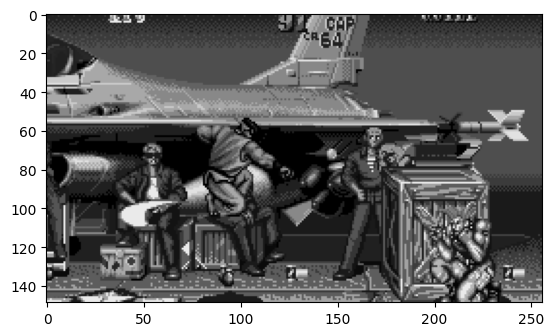

In [7]:
# Cross checking the shape of obserbation_space
plt.imshow(cv2.cvtColor(obs,cv2.COLOR_BGR2RGB))

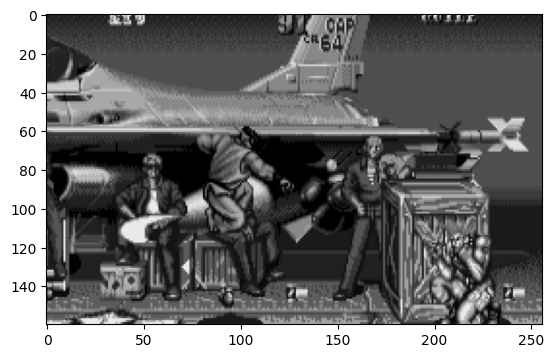

In [8]:
# Cross checking the shape of obserbation_space
plt.imshow(cv2.resize(cv2.cvtColor(obs,cv2.COLOR_BGR2RGB),(256,160)))

In [ ]:
#Try to run an instance of the game and observe the entity random actions:
done = False
for game in range(1):
    while not done:
        if done:
            obs = env.reset()
        env.render()
        x = env.action_space.sample()
        obs, reward, done, info = env.step(x)
        if (reward > 0):
            print(reward , env.get_action_meaning(x))
        time.sleep(0.01)

# **Hyperparameter tuning:**

Install required libraries for training:
- pip install torch==1.11.0+cu113 torchvision==0.12.0+cu113 torchaudio==0.11.0 --extra-index-url https://download.pytorch.org/whl/cu113
- pip install stable-baselines3[extra]==1.3.0
- pip install optuna==2.10.0

In [4]:
import os
# Importing optimization framework - HPO
import optuna
# PPO algorithm for Reinforcement Learning
from stable_baselines3 import PPO
# Eval policy method for metric calculation
from stable_baselines3.common.evaluation import evaluate_policy
# Import the sb3 monitor for logging
from stable_baselines3.common.monitor import Monitor
# Import the vec wrappers to vectorize and frame stack
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

e:\Projects\StreetFighter\.Fighter\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Setup directories for logs and models
LOG_DIR = './logs/'
OPT_DIR = './opt/'

In [ ]:
# Function to return test hyperparamenters - define the objective function
def optimize_ppo(trial):
    return{
        'n_steps':trial.suggest_int('n_steps', 2240, 3200),
        'gamma': trial.suggest_loguniform('gamma', 0.85, 0.95),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-8, 1e-6),
        'clip_range': trial.suggest_uniform('clip_range', 0.30, 0.4),
        'gae_lambda': trial.suggest_uniform('gae_lambda', 0.85, 0.95)
}


In [ ]:
# Run a training loop and return mean reward
def optimize_agent(trial):
    try:
        model_params = optimize_ppo(trial)
        
        # Create environment
        env = StreetFighter()
        env = Monitor(env, LOG_DIR)
        env = DummyVecEnv([lambda: env])
        env = VecFrameStack(env, 4, channels_order='last')  
        
        # Create algorithm
        model = PPO('CnnPolicy', env, tensorboard_log=LOG_DIR, verbose=0, **model_params)
        model.learn(total_timesteps=100000)
        
        # Evaluate model
        mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=10)
        env.close()

        SAVE_PATH = os.path.join(OPT_DIR, 'trial_{}_best_model'.format(trial.number))
        model.save(SAVE_PATH)
        
        return mean_reward
    
    except Exception as e:
        return -1000

After Running the trial Switch on tensorboard from terminal to view analytics:
- cd logs
- tensorboard --logdir=.
- http://localhost:6006/#scalars

In [ ]:
# Create the experiment
study = optuna.create_study(direction='maximize')
study.optimize(optimize_agent, n_trials=5, n_jobs=1)

In [ ]:
# Select the best Trial
study.best_params

# **Test out the Model:**

In [ ]:
model = PPO.load('./train/Reward_PPO3/best_model_210000')

In [ ]:
model = PPO.load('./BEST/HP-1/trial_2_best_model')

In [6]:
model = PPO.load(os.path.join(OPT_DIR,'trial_0_best_model.zip'))

In [7]:
env = StreetFighter()
env = Monitor(env, LOG_DIR)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order='last')

In [8]:
for episode in range(1): 
    obs = env.reset()
    done = False
    total_reward = 0
    while not done: 
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)
        env.render()
        if reward != 0:
            print (reward)
        time.sleep(0.01)
        total_reward += reward
    print('Total Reward for episode {} is {}'.format(total_reward, episode))
    time.sleep(2)

[39.772728]
[85.22727]
[400.]
[1000.]
[215.90909]
[500.]
[261.36365]
[1000.]
[198.86363]
[500.]
[22.727272]
[85.22727]
[500.]
[1000.]
[500.]
[2.840909]
[-500.]
[204.54546]
[500.]
[164.77272]
[500.]
[198.86363]
[500.]
[198.86363]
[500.]
[1000.]
[164.77272]
[500.]
[73.86364]
[3000.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[1000.]
[1000.]
[500.]
[-500.]
[250.]
[500.]
[1000.]
[227.27272]
[500.]
[116.47727]
[500.]
[96.59091]
[100.]
[198.86363]
[1000.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[100.]
[1000.]
[1000.]
[1000.]
[1000.]
[1000.]
[1000.]
[1000.]
[10000.]
[-2.840909]
[-500.]
[153.40909]
[300.]
[215.90909]
[500.]
[193.18182]
[500.]
[1000.]
[198.86363]
[500.]
[500.]
[119.318184]
[-500.]
[159.09091]
[400.]
[198.86363]
[500.]
[500.]
[321.02274]
Total Reward for episode [44663.64] is 0
